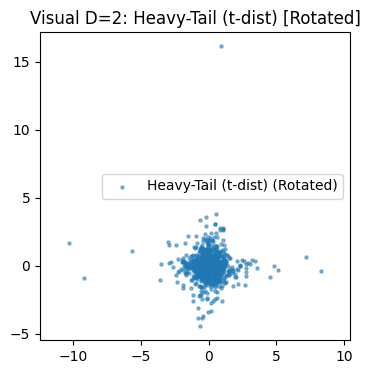

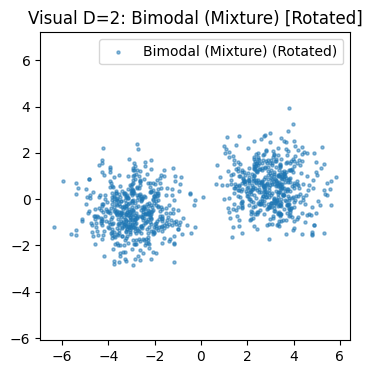

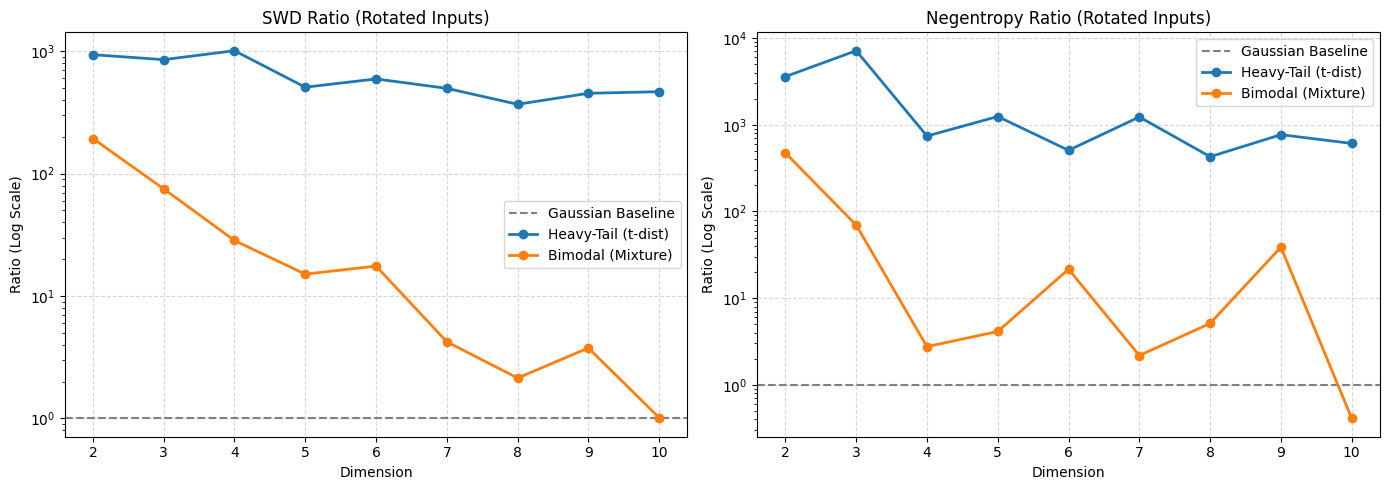

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Random seed
np.random.seed(1024)

class GaussianMetrics:
    """Metrics Implementation"""

    @staticmethod
    def swd(X, Y, num_projections=50):
        N, D = X.shape
        projections = np.random.randn(num_projections, D)
        projections /= np.linalg.norm(projections, axis=1, keepdims=True)
        X_proj = X @ projections.T
        Y_proj = Y @ projections.T
        X_proj.sort(axis=0)
        Y_proj.sort(axis=0)
        return np.mean((X_proj - Y_proj)**2)

    @staticmethod
    def negentropy(X):
        # J(y) approx (E[G(y)] - E[G(v)])^2
        E_G_gaussian = 0.37456
        abs_X = np.abs(X)
        G_val = np.where(abs_X > 20, abs_X - np.log(2), np.log(np.cosh(X)))
        E_G_data = np.mean(G_val, axis=0)
        # Sum over dimensions (assuming independence, which rotation destroys!)
        J = np.sum((E_G_data - E_G_gaussian)**2)
        return J

def generate_rotated_data(n_samples, dim, dist_type):
    """Generates data and applies a random rotation."""

    # 1. Generate Aligned Data (Source)
    if dist_type == 'Heavy-Tail (t-dist)':
        # Independent t-distributions
        X = np.random.standard_t(df=3, size=(n_samples, dim)) / np.sqrt(3)
    elif dist_type == 'Bimodal (Mixture)':
        # Bimodal only in the first dimension
        X = np.random.randn(n_samples, dim)
        mask = np.random.rand(n_samples) > 0.5
        X[mask, 0] += 3.0 # Make it very obvious
        X[~mask, 0] -= 3.0

    # 2. Generate Random Rotation Matrix (QR decomposition)
    # This mixes the dimensions
    H = np.random.randn(dim, dim)
    Q, R = np.linalg.qr(H)

    # 3. Apply Rotation
    X_rotated = X @ Q
    return X_rotated

def whiten_data(X):
    """
    Standard PCA/Cholesky Whitening.
    CRITICAL: This only decorrelates (2nd order).
    It DOES NOT align independent components (High order).
    """
    mu = np.mean(X, axis=0)
    cov = np.cov(X, rowvar=False)
    if X.shape[1] == 1:
        return (X - mu) / np.std(X)
    try:
        L = np.linalg.cholesky(cov)
        return (X - mu) @ np.linalg.inv(L).T
    except:
        return (X - mu) / np.std(X, axis=0)

# --- Experiment ---

dims = range(2, 11) # Start from 2 to allow rotation
distributions = ['Heavy-Tail (t-dist)', 'Bimodal (Mixture)']
ratios = {dist: {'SWD': [], 'Negentropy': []} for dist in distributions}

N = 50000

for d in dims:
    # Baseline
    G_ref1 = np.random.randn(N, d)
    G_ref2 = np.random.randn(N, d)

    base_swd = GaussianMetrics.swd(G_ref1, G_ref2)
    # Ensure baseline isn't zero
    base_swd = max(base_swd, 1e-9)

    # Calculate Negentropy Baseline (Average of many runs to be stable)
    # Since G_ref1 is perfectly aligned Gaussian, its Negentropy is low.
    base_negent = GaussianMetrics.negentropy(G_ref1)
    base_negent = max(base_negent, 1e-9)

    for dist_name in distributions:
        # Generate & Rotate
        X_rot = generate_rotated_data(N, d, dist_name)

        # Visualize D=2 Rotated
        if d == 2:
            plt.figure(figsize=(4, 4))
            plt.scatter(X_rot[:1000, 0], X_rot[:1000, 1], s=5, alpha=0.5, label=f"{dist_name} (Rotated)")
            plt.title(f"Visual D=2: {dist_name} [Rotated]")
            plt.axis('equal')
            plt.legend()
            plt.show()

        # Whiten (Standard Preprocessing)
        X_white = whiten_data(X_rot)

        # Compute Ratios
        val_swd = GaussianMetrics.swd(X_white, G_ref1)
        ratios[dist_name]['SWD'].append(val_swd / base_swd)

        val_negent = GaussianMetrics.negentropy(X_white)
        ratios[dist_name]['Negentropy'].append(val_negent / base_negent)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['SWD', 'Negentropy']

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.axhline(y=1.0, color='gray', linestyle='--', label='Gaussian Baseline')

    for dist_name in distributions:
        ax.plot(dims, ratios[dist_name][metric], marker='o', linewidth=2, label=dist_name)

    ax.set_title(f"{metric} Ratio (Rotated Inputs)")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Ratio (Log Scale)")
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()